
---

# 📈 ***`Logistic Regression in Machine Learning for Data Science`*** 🚀  

## ✅ **What is Logistic Regression?**  
📌 **Logistic Regression** is a **supervised learning algorithm** used for **classification tasks**. Despite its name, it's designed to predict **categorical outcomes**, not continuous values.  

✔️ **Mainly used for binary classification** (e.g., Yes/No, Spam/Not Spam).  
✔️ Can be extended to **multiclass classification** (e.g., Dog/Cat/Bird).  
✔️ Outputs **probabilities** for class predictions.  

---

## 🎯 **1. Why Not Use Linear Regression for Classification?**  

**Linear Regression** is unsuitable for classification because:  
❌ It predicts continuous outputs without a probability boundary.  
❌ It is prone to **outlier sensitivity** in classification tasks.  
❌ It cannot ensure outputs are between **0 and 1**.  

### 🔹 **Logistic Regression Solves This Using the Sigmoid (Logistic) Function**

---

## 📈 **2. Mathematical Foundation of Logistic Regression**  

### 🔹 **Step 1: Linear Model**
Logistic Regression first computes a linear combination of input features:

$
z = \theta_0 + \theta_1X_1 + \theta_2X_2 + ... + \theta_nX_n
$

---

### 🔹 **Step 2: Sigmoid (Logistic) Function**
The sigmoid function maps any real value into a probability range between **0 and 1**:

$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

- **If $ \sigma(z) > 0.5 $** → Predict **Class 1**  
- **If $ \sigma(z) \leq 0.5 $** → Predict **Class 0**  

---

### 🔹 **Step 3: Probability Interpretation**  
$
P(Y = 1 | X) = \sigma(z) = \frac{1}{1 + e^{-z}}
$

$
P(Y = 0 | X) = 1 - \sigma(z)
$

---

### 🔹 **Step 4: Decision Boundary**
Logistic Regression creates a **linear decision boundary** by setting:

$
\sigma(z) = 0.5 \quad \Rightarrow \quad z = 0
$

---

## 📉 **3. Cost Function for Logistic Regression**  

📌 Instead of Mean Squared Error (MSE), Logistic Regression uses the **Log Loss (Cross-Entropy Loss)** to measure model performance:

$
J(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \left[ Y_i \log(\hat{Y}_i) + (1 - Y_i) \log(1 - \hat{Y}_i) \right]
$

Where:  
- **$ Y_i $** → Actual label (0 or 1).  
- **$ \hat{Y}_i $** → Predicted probability.  

✔️ The model optimizes this cost function using **Gradient Descent** or **Stochastic Gradient Descent (SGD)**.  

---

## 🏹 **4. Implementing Logistic Regression in Python**  

### 📁 **Dataset: Predicting Diabetes**  

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv", header=None)

# Assign Column Names
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
               'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

# Splitting Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


Confusion Matrix:
 [[79 20]
 [18 37]]



---

## 📊 **5. Model Evaluation for Logistic Regression**  

### 🔹 **Confusion Matrix**
- **True Positive (TP):** Correctly predicted **positive** cases.  
- **True Negative (TN):** Correctly predicted **negative** cases.  
- **False Positive (FP):** Incorrectly predicted **positive** cases (Type I error).  
- **False Negative (FN):** Incorrectly predicted **negative** cases (Type II error).  

---

### 🔹 **Performance Metrics**

| **Metric** | **Formula** | **When to Use** |
|-------------|--------------|------------------|
| **Accuracy** | $ \frac{TP + TN}{TP + TN + FP + FN} $ | Balanced datasets |
| **Precision** | $ \frac{TP}{TP + FP} $ | Focus on reducing **False Positives** |
| **Recall (Sensitivity)** | $ \frac{TP}{TP + FN} $ | Focus on reducing **False Negatives** |
| **F1 Score** | $ 2 \times \frac{Precision \times Recall}{Precision + Recall} $ | For **imbalanced datasets** |
| **AUC-ROC Score** | Area under ROC curve | Measures model's ability to distinguish classes |

---

### 📌 **ROC Curve and AUC Score**
- **ROC Curve** plots **True Positive Rate (TPR)** vs **False Positive Rate (FPR)**.  
- **AUC Score** ranges from **0 to 1** — higher values indicate better performance.  

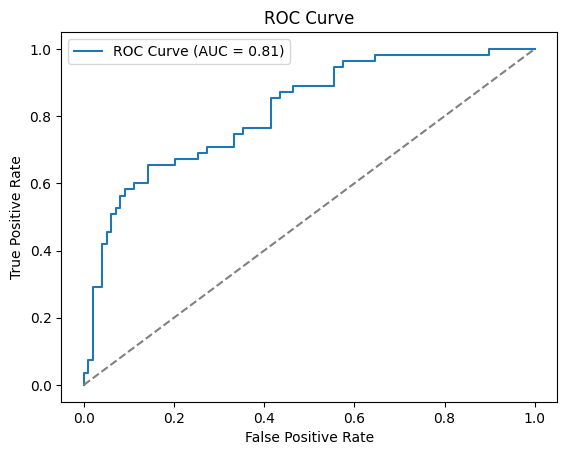

AUC Score: 0.8146923783287419


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability Predictions
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Compute ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)


---

## 🔍 **6. Types of Logistic Regression**  

| **Type** | **Description** | **Example** |
|-----------|----------------|---------------|
| **Binary Logistic Regression** | Predicts between **two classes** | Spam/Not Spam, Fraud/Not Fraud |
| **Multinomial Logistic Regression** | Predicts between **3 or more classes** without ordering | Dog/Cat/Bird |
| **Ordinal Logistic Regression** | Predicts between **3 or more ordered classes** | Low/Medium/High Risk |

---

## 🛠️ **7. Regularization in Logistic Regression**  

To prevent **overfitting**, Logistic Regression includes **L1 (Lasso)** and **L2 (Ridge)** regularization:  

✅ **L1 (Lasso):** Shrinks some coefficients to **zero** for feature selection.  
✅ **L2 (Ridge):** Shrinks coefficients but **keeps all features**.  
✅ **ElasticNet:** Combines **L1 + L2** for better flexibility.  

In [11]:
# Logistic Regression with Regularization
log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear')
log_reg_l2 = LogisticRegression(penalty='l2')

---

## 🏆 **8. Key Takeaways**  

✔️ **Logistic Regression is a powerful, interpretable, and efficient algorithm for binary/multi-class classification.**  
✔️ Uses the **Sigmoid Function** to predict probabilities.  
✔️ Optimized using **Log Loss (Cross-Entropy Loss)**.  
✔️ Evaluated using metrics like **Accuracy, Precision, Recall, and AUC-ROC**.  
✔️ Regularization techniques like **L1 (Lasso)** and **L2 (Ridge)** improve model generalization.  

💡 **Pro Tip:** For imbalanced datasets, focus on **Precision, Recall**, or **F1 Score** rather than accuracy alone.

---


## ***`Further Practice`***


In [12]:
# import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [13]:
# Generate a synthetic binary classification dataset with 100 samples and 2 features
X, y = make_classification(
    n_samples=100,        # Number of samples
    n_features=2,        # Total number of features
    n_informative=1,     # Number of informative features
    n_redundant=0,       # Number of redundant features
    n_classes=2,         # Number of classes
    n_clusters_per_class=1,  # Number of clusters per class
    random_state=41,     # Seed for reproducibility
    hypercube=False,     # Use a hypercube (False for a non-hypercube)
    class_sep=10         # Separation between classes
)

In [14]:
X[0:10]

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794]])

In [15]:
y[0:10]

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0])

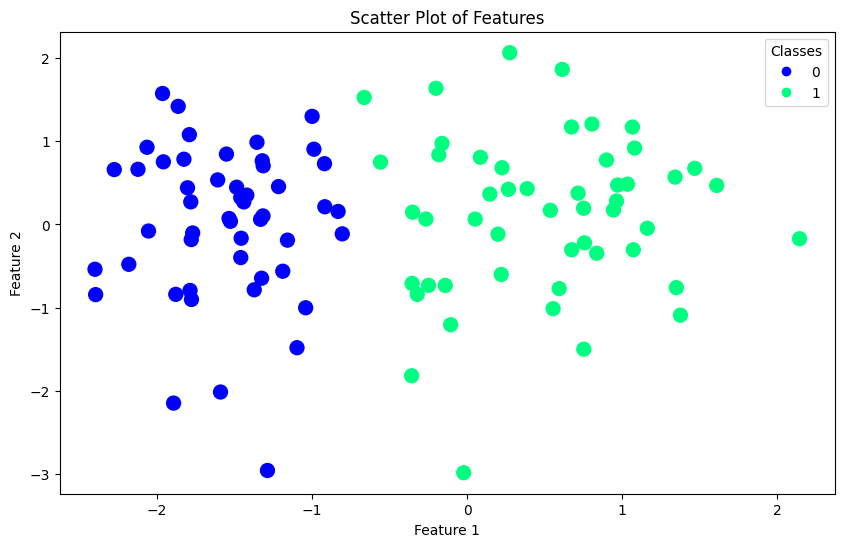

In [16]:
# Set figure size to 10x6 inches
plt.figure(figsize=(10, 6))

# Create a scatter plot of the first two features in X, colored by y, using the 'winter' colormap
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

# Add labels for the x and y axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Add a title to the plot
plt.title('Scatter Plot of Features')

# Add a legend
plt.legend(*scatter.legend_elements(), title="Classes")

# Display the plot
plt.show()

In [17]:
def perceptron(X, y):
    # Insert a bias term (1) into the feature matrix X
    X = np.insert(X, 0, 1, axis=1)
    
    # Initialize weights to ones for each feature
    weights = np.ones(X.shape[1])
    lr = 0.1  # Set the learning rate
    
    # Train the perceptron for 1000 iterations
    for i in range(1000):
        # Randomly select an index for training
        j = np.random.randint(0, 100)
        
        # Calculate predicted output using the step function
        y_hat = step(np.dot(X[j], weights))
        
        # Update weights based on the prediction error
        weights = weights + lr * (y[j] - y_hat) * X[j]
        
    # Return the bias weight and the weights for the features
    return weights[0], weights[1:]

In [18]:
def step(z):
    # Return 1 if input z is greater than 0, otherwise return 0
    return 1 if z > 0 else 0

In [19]:
# Train the perceptron and obtain the intercept and coefficients
intercept_, coef_ = perceptron(X, y)

In [20]:
print("Coefficent:",coef_)
print("Intercept:",intercept_)

Coefficent: [1.34067917 0.03197641]
Intercept: 0.9


In [21]:
# Calculate the slope (m) and y-intercept (b) of the decision boundary
m = -(coef_[0] / coef_[1])  # Slope of the line
b = -(intercept_ / coef_[1])  # Y-intercept of the line

In [22]:
# Generate x values from -3 to 3 and calculate corresponding y values using the line equation
x_input = np.linspace(-3, 3, 100)  # 100 points between -3 and 3
y_input = m * x_input + b  # Calculate y values based on the line equation y = mx + b

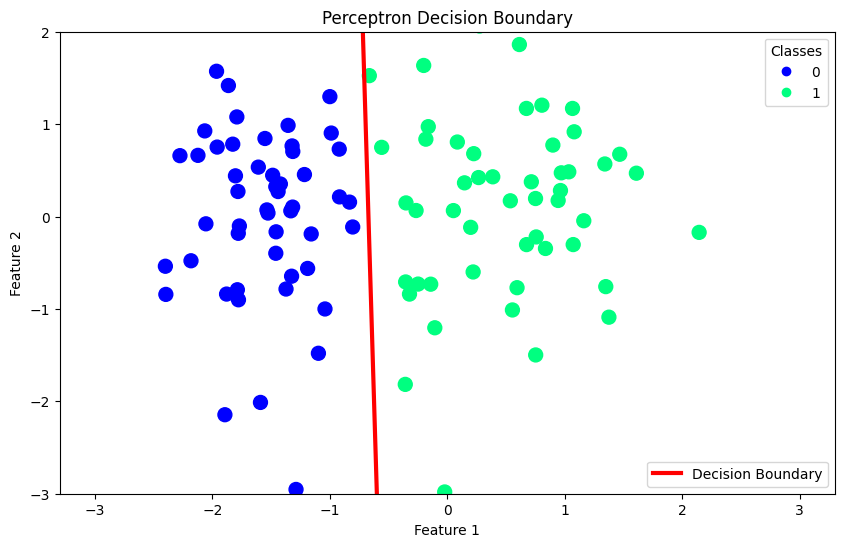

In [23]:
# Create a figure with specified size
plt.figure(figsize=(10, 6))

# Plot the decision boundary line in red
plt.plot(x_input, y_input, color='red', linewidth=3, label='Decision Boundary')

# Scatter plot of the original data points, colored by their class
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

# Set the limits for the y-axis
plt.ylim(-3, 2)

# Add labels to the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Add a title to the plot
plt.title('Perceptron Decision Boundary')

# Create the first legend for classes
legend1 = plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")

# Create the second legend for the decision boundary below the first
plt.legend(['Decision Boundary'], loc='lower right')

# Add the classes legend back to the plot
plt.gca().add_artist(legend1)

# Display the plot
plt.show()


In [24]:
def perceptron(X, y):
    # Initialize lists to store slopes (m) and intercepts (b)
    m = []
    b = []
    
    # Add a bias term (1) to the feature matrix X
    X = np.insert(X, 0, 1, axis=1)
    # Initialize weights with ones
    weights = np.ones(X.shape[1])
    # Set the learning rate
    lr = 0.1
    
    # Train for 200 iterations
    for i in range(200):
        # Randomly select an index from the dataset
        j = np.random.randint(0, 100)
        # Calculate predicted value using a step function
        y_hat = step(np.dot(X[j], weights))
        # Update weights based on prediction error
        weights = weights + lr * (y[j] - y_hat) * X[j]
        
        # Calculate slope and intercept for the decision boundary
        m.append(-(weights[1] / weights[2]))
        b.append(-(weights[0] / weights[2]))
        
    return m, b  # Return lists of slopes and intercepts

In [25]:
m,b = perceptron(X,y)

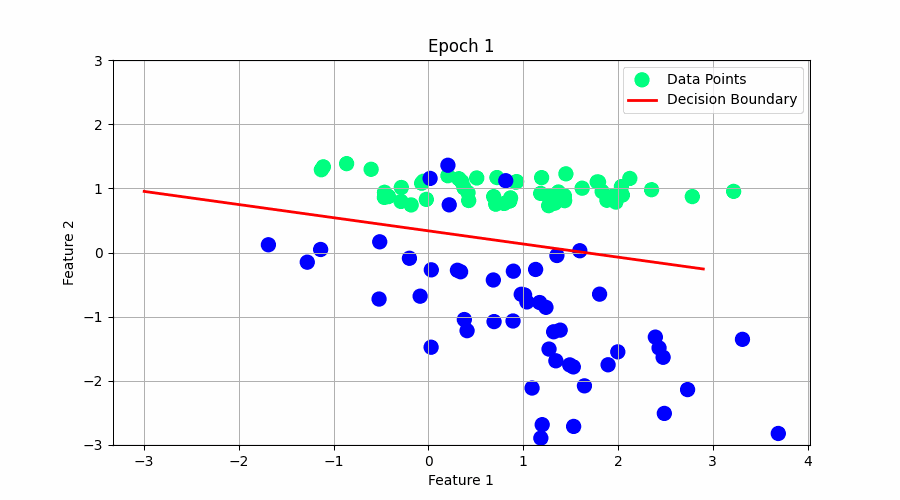

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_classification
from IPython.display import Image

# Sample data generation for logistic regression
np.random.seed(0)
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)
X = X[:, :2]  # Take only the first two features for 2D plotting

# Placeholder for slopes and intercepts for animation
num_frames = 200
m = np.random.rand(num_frames, 2) * 2 - 1  # Random slopes for two features
b = np.random.rand(num_frames) * 2 - 1  # Random intercepts

# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(9, 5))

# Generate x values for the line to be plotted
x_i = np.arange(-3, 3, 0.1)

# Scatter plot of the data points (X, y)
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, label='Data Points')

# Initial line plot for the logistic regression boundary
line, = ax.plot(x_i, x_i * m[0, 0] + b[0], 'r-', linewidth=2, label='Decision Boundary')

# Set limits for the y-axis
plt.ylim(-3, 3)

# Set title and labels
ax.set_title('Logistic Regression Animation', fontsize=16)
ax.set_xlabel('Feature 1')  # Label for the x-axis
ax.set_ylabel('Feature 2')  # Label for the y-axis
ax.legend()  # Show legend
ax.grid(True)  # Enable grid

# Function to update the plot for each frame of the animation
def update(i):
    label = 'Epoch {0}'.format(i + 1)  # Create a label for the current epoch
    line.set_ydata(x_i * m[i, 0] + b[i])  # Update the line with current parameters
    ax.set_title(label)  # Update title to show current epoch

# Create an animation that updates the plot at each frame
anim = FuncAnimation(fig, update, repeat=True, frames=num_frames, interval=100)

# Save the animation as a GIF
anim.save('logistic_regression_animation.gif', writer=PillowWriter(fps=10))

# Close the figure to avoid displaying it
plt.close(fig)

# Display the GIF in Jupyter Notebook
Image(filename='logistic_regression_animation.gif')

In [27]:
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [28]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [29]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

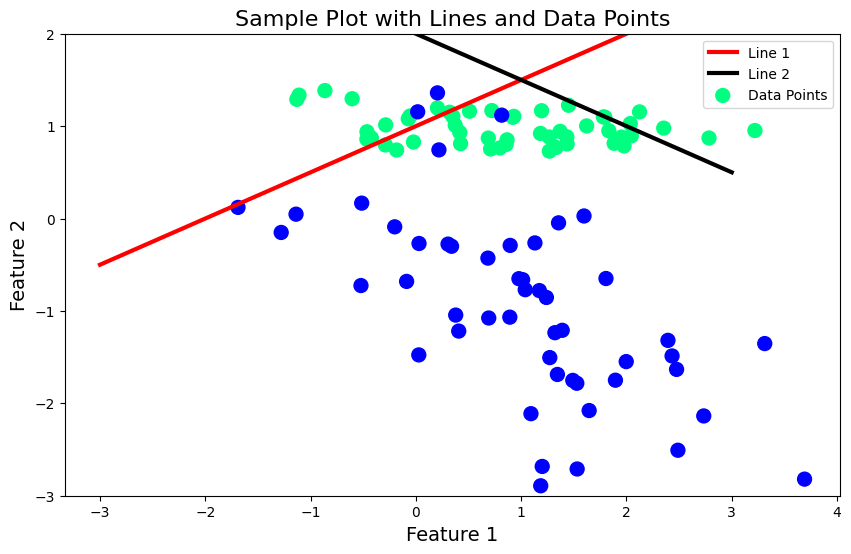

In [30]:
# Sample data generation for demonstration
np.random.seed(0)
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)
X = X[:, :2]  # Take only the first two features for 2D plotting

# Example input data for lines
x_input = np.linspace(-3, 3, 100)
y_input = 0.5 * x_input + 1  # Line 1
x_input1 = np.linspace(-3, 3, 100)
y_input1 = -0.5 * x_input1 + 2  # Line 2

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the lines
plt.plot(x_input, y_input, color='red', linewidth=3, label='Line 1')  # Line 1
plt.plot(x_input1, y_input1, color='black', linewidth=3, label='Line 2')  # Line 2

# Scatter plot of the data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, label='Data Points')

# Set limits for the y-axis
plt.ylim(-3, 2)

# Set title and labels
plt.title('Sample Plot with Lines and Data Points', fontsize=16)
plt.xlabel('Feature 1', fontsize=14)  # Label for the x-axis
plt.ylabel('Feature 2', fontsize=14)  # Label for the y-axis

# Show legend
plt.legend()

# Display the plot
plt.show()

---